
# FINAL v4 – Springer Submission Ready Password Strength Framework
Generated: 2026-02-16

## Evaluation Protocol

• Single stratified train/test split (80/20)  
• Same split used for RF, LSTM, Transformer  
• Macro-F1 reported  
• Macro ROC-AUC (OvR) reported  
• Confusion matrices reported  
• Training time measured  

This version avoids leakage and ensures fair comparison.


In [2]:

import re
import math
import random
import time
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## Load RockYou

In [3]:

def load_rockyou(path, max_samples=200000):
    pwds = []
    with open(path, "r", encoding="latin-1") as f:
        for line in f:
            pwd = re.sub(r'[^\x20-\x7E]', '', line.strip())
            if 4 <= len(pwd) <= 32:
                pwds.append(pwd)
            if len(pwds) >= max_samples:
                break
    return pwds

passwords = load_rockyou("rockyou.txt")
print("Loaded:", len(passwords))


Loaded: 200000


## Feature Engineering

In [4]:

CHARSET = 94
HASH_RATE = 1e10

def entropy(p):
    c = Counter(p)
    L = len(p)
    return -sum((v/L)*math.log2(v/L) for v in c.values())

def log_crack_time(p):
    L = len(p)
    return L * np.log10(CHARSET) - np.log10(HASH_RATE)

entropy_vals = np.array([entropy(p) for p in passwords])
crack_time = np.array([log_crack_time(p) for p in passwords])
lengths = np.array([len(p) for p in passwords])

X_tab = np.column_stack([entropy_vals, crack_time, lengths])


## Hybrid Labeling

In [5]:

freq_counter = Counter(passwords)
freq_df = pd.DataFrame(freq_counter.items(), columns=["password", "freq"])
freq_df = freq_df.sort_values("freq", ascending=False).reset_index(drop=True)

top_5 = set(freq_df.iloc[:int(0.05*len(freq_df))]["password"])
patterns = ["123", "abc", "qwerty", "password", "111"]

labels = []
for p, ent, L in zip(passwords, entropy_vals, lengths):
    if p in top_5:
        labels.append(0)
    elif any(pt in p.lower() for pt in patterns):
        labels.append(1)
    elif ent > 3.5 and L >= 12:
        labels.append(3)
    else:
        labels.append(2)

labels = np.array(labels)
print(pd.Series(labels).value_counts())


2    183004
0     10000
1      6889
3       107
Name: count, dtype: int64


## Train/Test Split

In [6]:

X_train_tab, X_test_tab, y_train, y_test, idx_train, idx_test = train_test_split(
    X_tab, labels, np.arange(len(labels)),
    test_size=0.2, random_state=SEED, stratify=labels)

print("Train size:", len(y_train))
print("Test size:", len(y_test))


Train size: 160000
Test size: 40000


## Random Forest Evaluation

In [7]:

start = time.time()

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train_tab, y_train)

rf_time = time.time() - start

rf_pred = rf.predict(X_test_tab)
rf_prob = rf.predict_proba(X_test_tab)

rf_f1 = f1_score(y_test, rf_pred, average='macro')

y_bin = label_binarize(y_test, classes=[0,1,2,3])
rf_auc = roc_auc_score(y_bin, rf_prob, average="macro", multi_class="ovr")

print("RF Training Time (sec):", rf_time)
print("RF Macro-F1:", rf_f1)
print("RF Macro ROC-AUC:", rf_auc)
print("Confusion Matrix (RF):")
print(confusion_matrix(y_test, rf_pred))


RF Training Time (sec): 3.1678781509399414
RF Macro-F1: 0.4155950847940058
RF Macro ROC-AUC: 0.7317744004741525
Confusion Matrix (RF):
[[  841   495   664     0]
 [  269   864   236     9]
 [10644 10438 15519     0]
 [    0     0     0    21]]


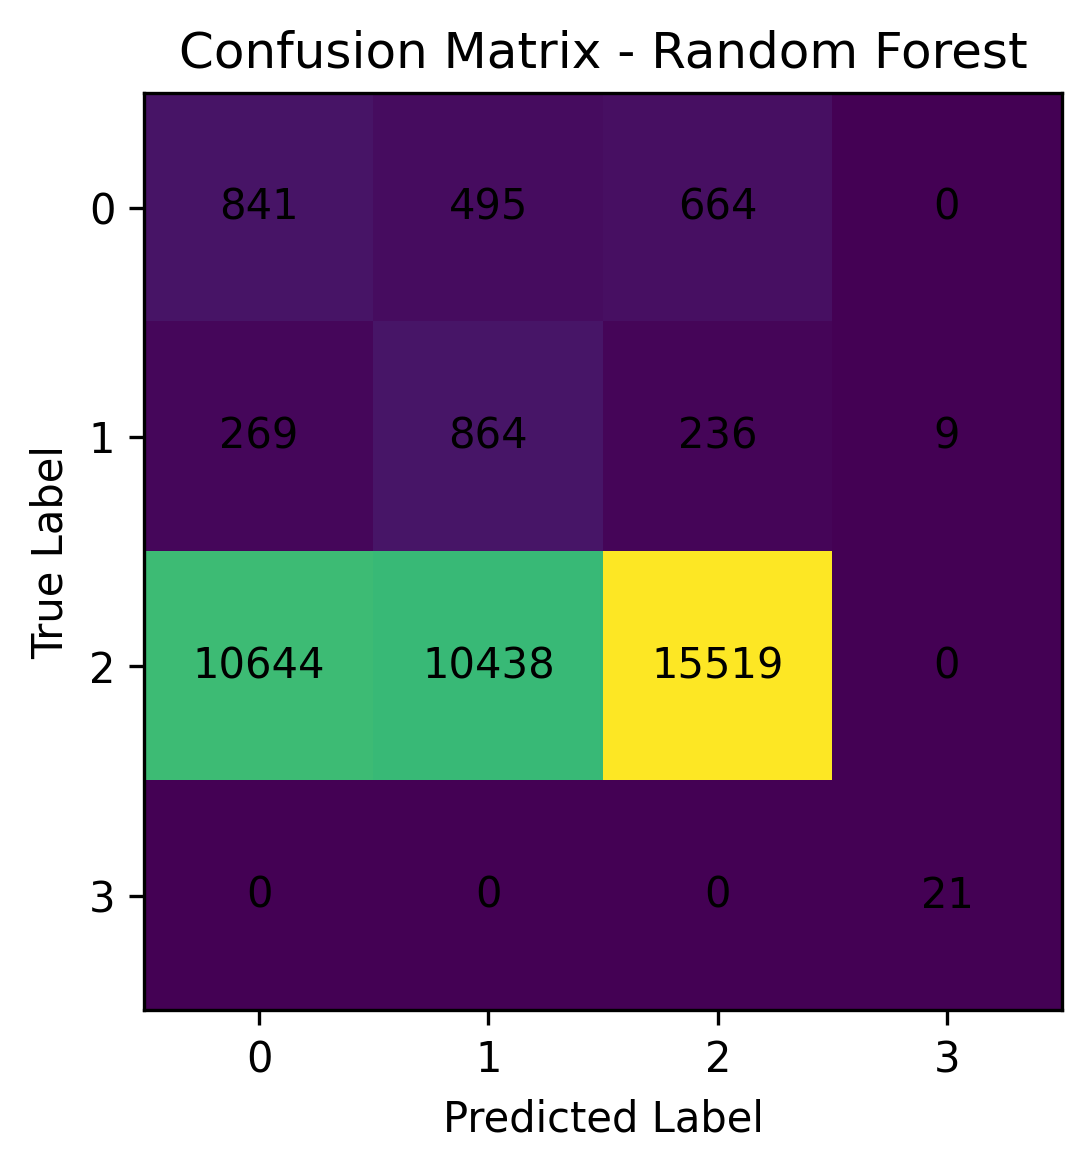

In [8]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4), dpi=300)
plt.imshow(cm_rf)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(4))
plt.yticks(range(4))

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("Confusion_Matrix_RF.png")
plt.show()


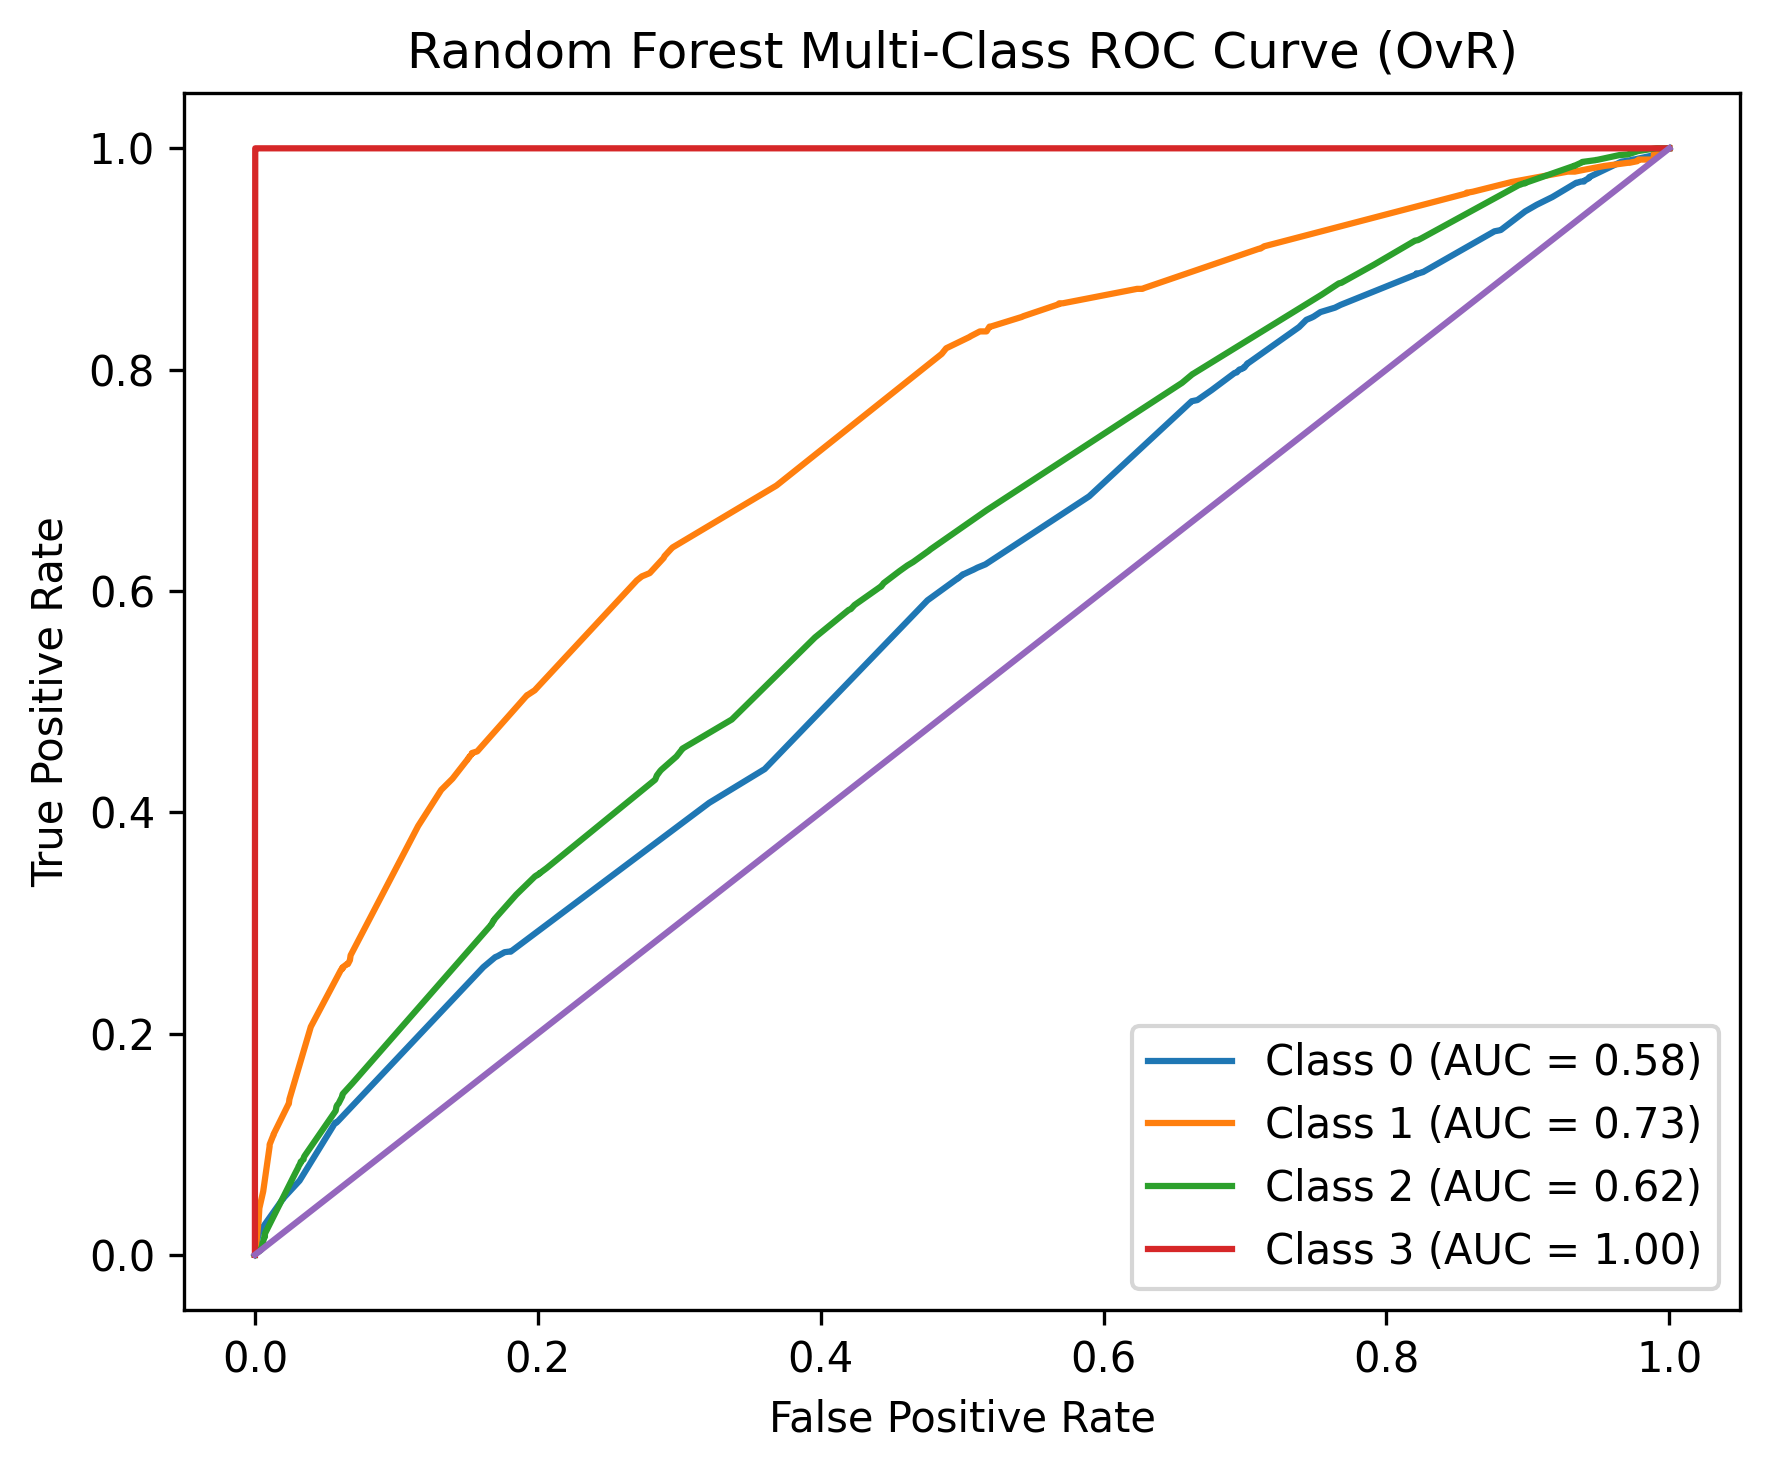

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

classes = [0,1,2,3]
y_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(6,5), dpi=300)

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], rf_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest Multi-Class ROC Curve (OvR)")
plt.legend()
plt.tight_layout()
plt.savefig("RF_ROC_Curve.png")
plt.show()


## Sequence Encoding

In [9]:

chars = sorted(set("".join(passwords)))
char2idx = {c:i+1 for i,c in enumerate(chars)}
MAX_LEN = 32

def encode(p):
    seq = [char2idx[c] for c in p if c in char2idx]
    return (seq + [0]*MAX_LEN)[:MAX_LEN]

X_seq = np.array([encode(p) for p in passwords])

X_train_seq = X_seq[idx_train]
X_test_seq = X_seq[idx_test]


## PyTorch Dataset

In [10]:

class PasswordDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(PasswordDataset(X_train_seq, y_train), batch_size=256, shuffle=True)
test_loader = DataLoader(PasswordDataset(X_test_seq, y_test), batch_size=256)


## LSTM Model (7 Epochs)

In [11]:

class LSTMModel(nn.Module):
    def __init__(self, vocab, emb=128, hid=256, out=4):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hid, out)
    def forward(self, x):
        x = self.emb(x)
        _, (h, _) = self.lstm(x)
        x = self.dropout(h[-1])
        return self.fc(x)

model_lstm = LSTMModel(len(char2idx)+1).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

start = time.time()

for epoch in range(7):
    model_lstm.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_lstm(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

lstm_time = time.time() - start

model_lstm.eval()
preds, probs = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        out = model_lstm(Xb)
        prob = torch.softmax(out, dim=1).cpu().numpy()
        pred = np.argmax(prob, axis=1)
        preds.extend(pred)
        probs.extend(prob)

lstm_f1 = f1_score(y_test, preds, average='macro')
lstm_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")

print("LSTM Training Time (sec):", lstm_time)
print("LSTM Macro-F1:", lstm_f1)
print("LSTM Macro ROC-AUC:", lstm_auc)
print("Confusion Matrix (LSTM):")
print(confusion_matrix(y_test, preds))


Epoch 1 Loss: 0.2535641370177269
Epoch 2 Loss: 0.1987286538243294
Epoch 3 Loss: 0.19453454045057297
Epoch 4 Loss: 0.18989386637210845
Epoch 5 Loss: 0.18826130353212356
Epoch 6 Loss: 0.18362639286518098
Epoch 7 Loss: 0.18047944573163988
LSTM Training Time (sec): 458.5246591567993
LSTM Macro-F1: 0.48378528261270565
LSTM Macro ROC-AUC: 0.8934497357600926
Confusion Matrix (LSTM):
[[    0    76  1924     0]
 [    0  1373     5     0]
 [    0    29 36572     0]
 [    0     0    21     0]]


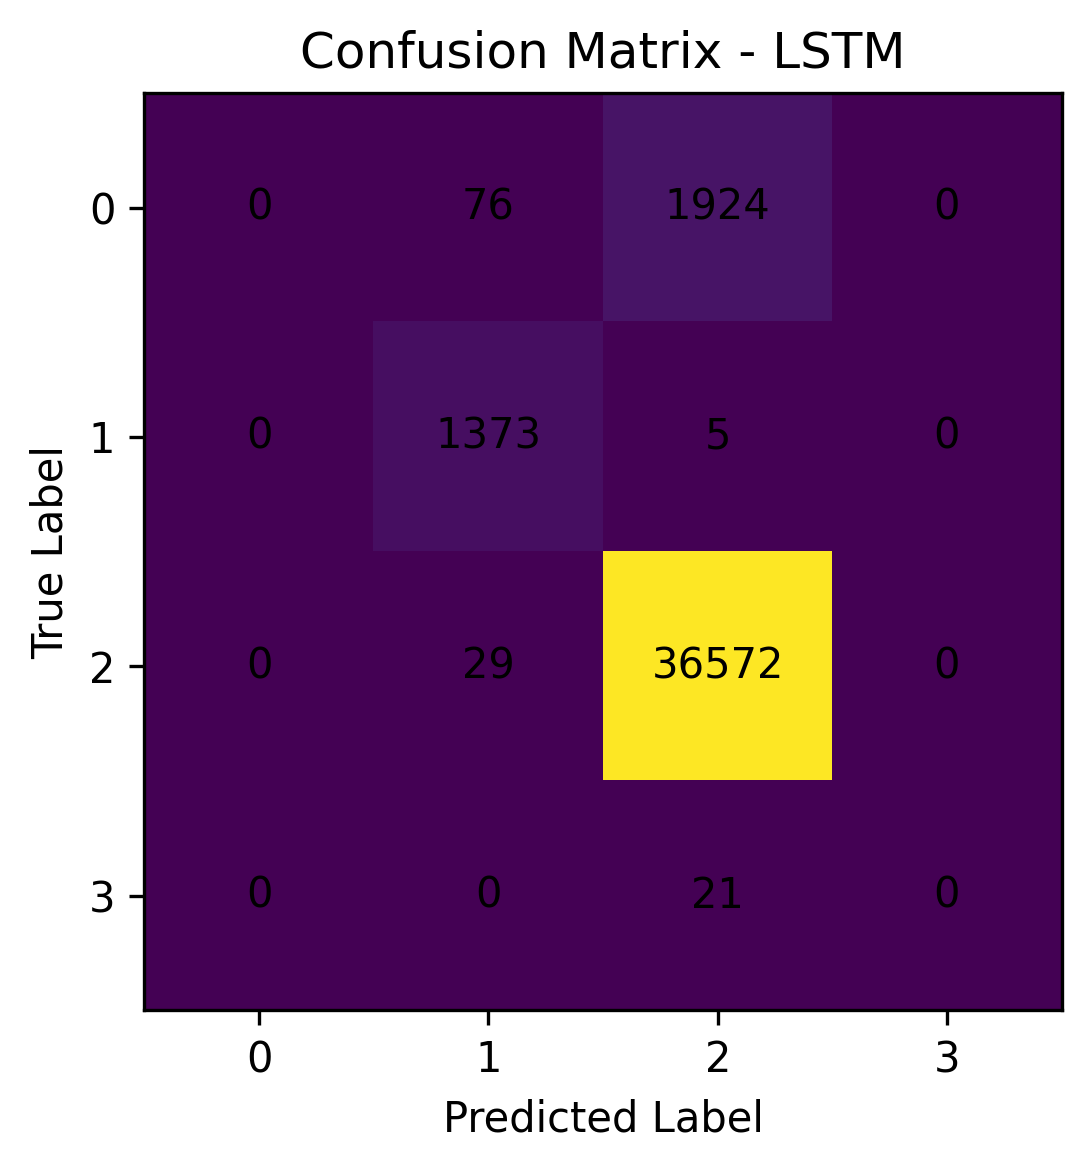

In [14]:
cm_lstm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4), dpi=300)
plt.imshow(cm_lstm)
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(4))
plt.yticks(range(4))

for i in range(cm_lstm.shape[0]):
    for j in range(cm_lstm.shape[1]):
        plt.text(j, i, cm_lstm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("Confusion_Matrix_LSTM.png")
plt.show()


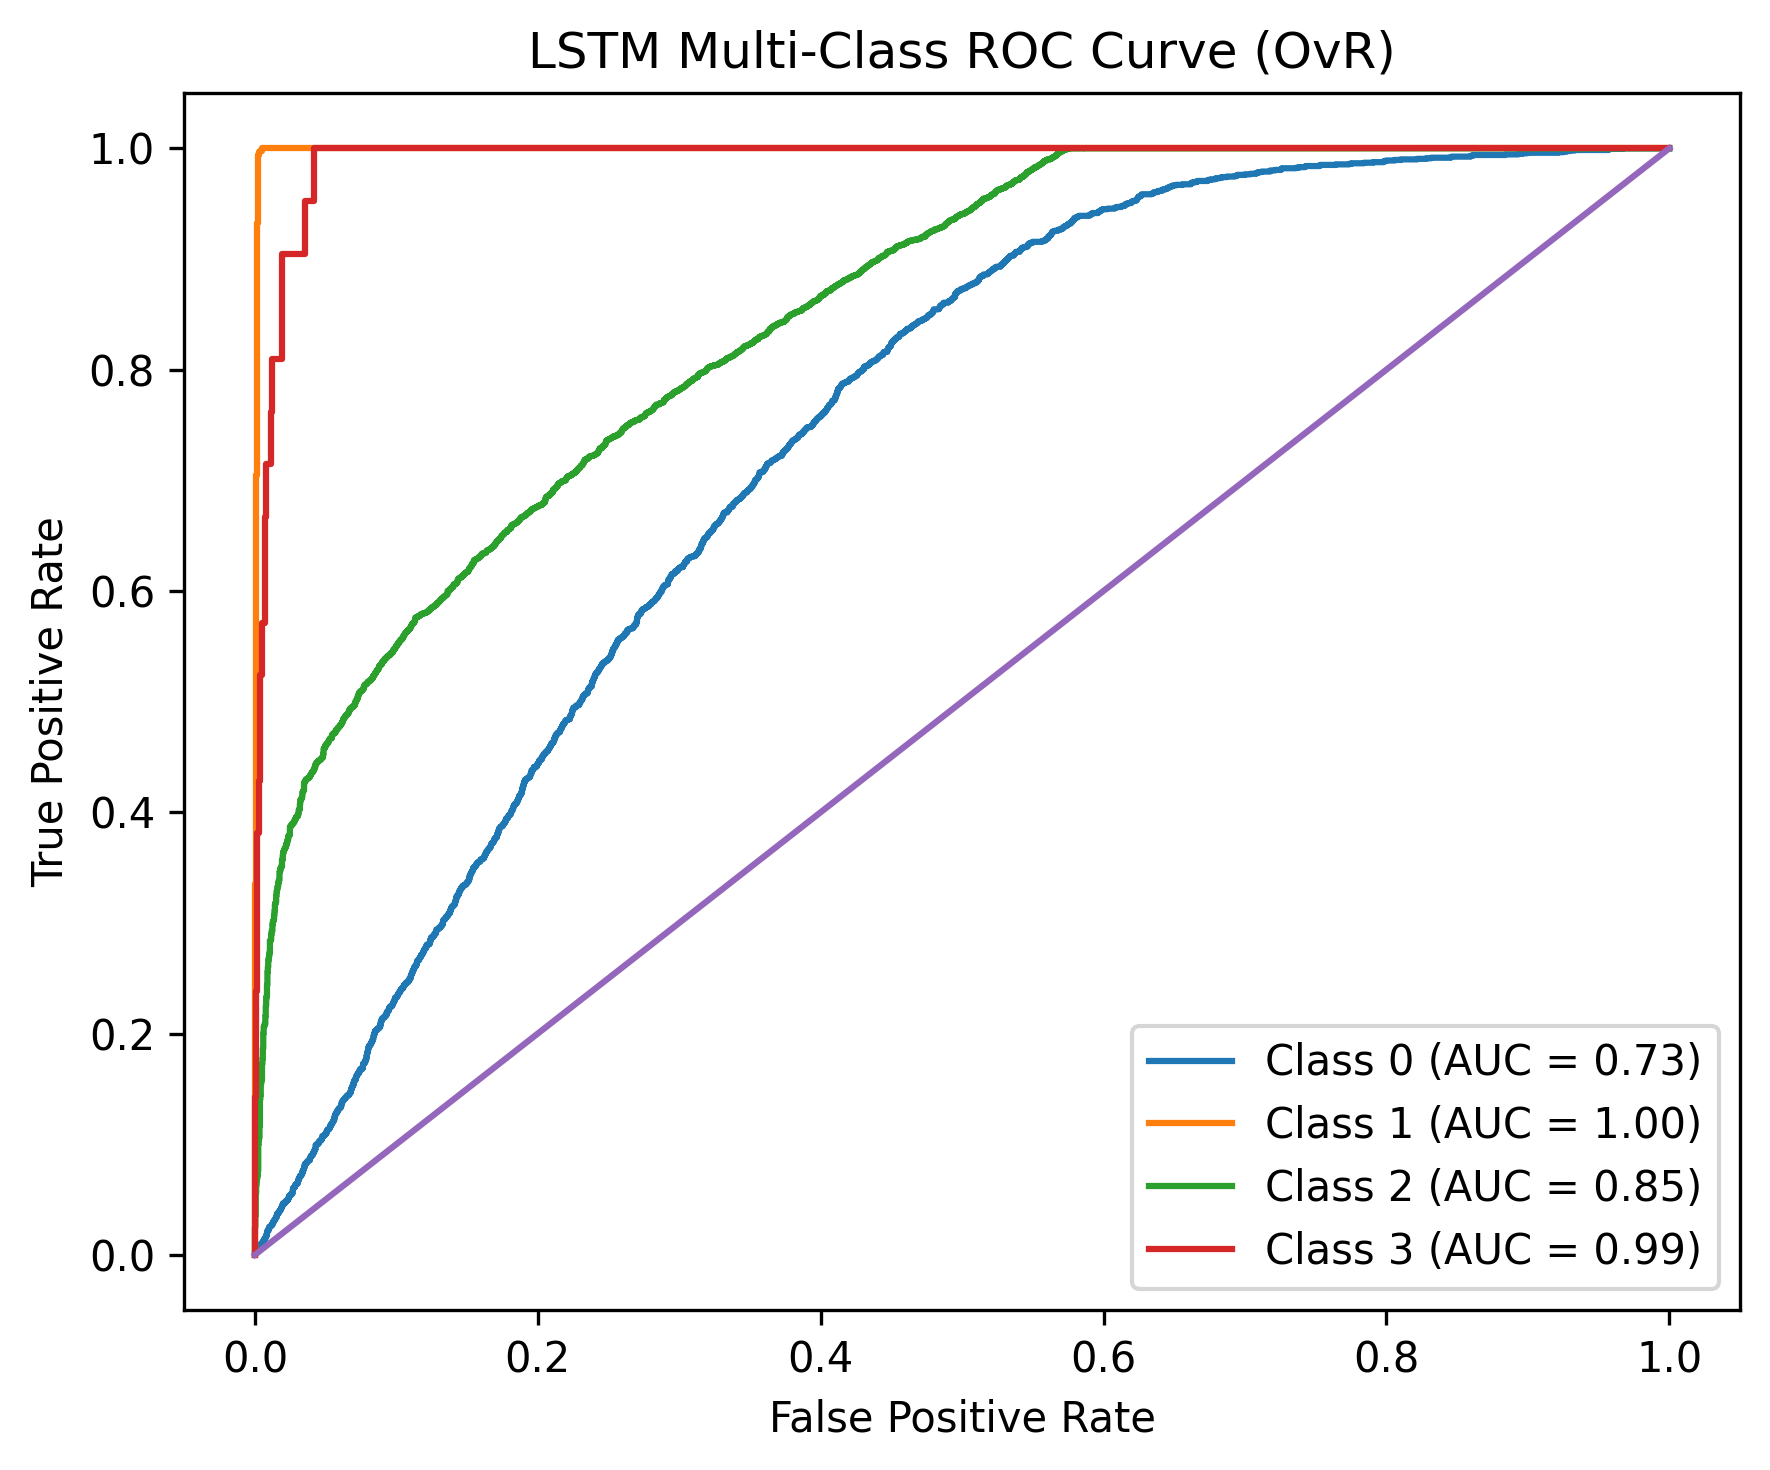

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

classes = [0,1,2,3]
y_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(6,5), dpi=300)

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], np.array(probs)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM Multi-Class ROC Curve (OvR)")
plt.legend()
plt.tight_layout()
plt.savefig("LSTM_ROC_Curve.png")
plt.show()


## Transformer Model (7 Epochs)

In [16]:

class TransformerModel(nn.Module):
    def __init__(self, vocab, emb=128, heads=4, layers=2, out=4):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb, nhead=heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(emb, out)
    def forward(self, x):
        x = self.emb(x).permute(1,0,2)
        x = self.transformer(x)
        x = x.mean(dim=0)
        x = self.dropout(x)
        return self.fc(x)

model_trans = TransformerModel(len(char2idx)+1).to(device)
optimizer = torch.optim.Adam(model_trans.parameters(), lr=0.001)

start = time.time()

for epoch in range(7):
    model_trans.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_trans(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

trans_time = time.time() - start

model_trans.eval()
preds, probs = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        out = model_trans(Xb)
        prob = torch.softmax(out, dim=1).cpu().numpy()
        pred = np.argmax(prob, axis=1)
        preds.extend(pred)
        probs.extend(prob)

trans_f1 = f1_score(y_test, preds, average='macro')
trans_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")

print("Transformer Training Time (sec):", trans_time)
print("Transformer Macro-F1:", trans_f1)
print("Transformer Macro ROC-AUC:", trans_auc)
print("Confusion Matrix (Transformer):")
print(confusion_matrix(y_test, preds))


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1 Loss: 0.2468962060570717
Epoch 2 Loss: 0.22413355659246445
Epoch 3 Loss: 0.22066985425949096
Epoch 4 Loss: 0.21925426279306412
Epoch 5 Loss: 0.21814103995561598
Epoch 6 Loss: 0.21686562815904617
Epoch 7 Loss: 0.2160260285973549
Transformer Training Time (sec): 2464.2552552223206
Transformer Macro-F1: 0.44305826596041264
Transformer Macro ROC-AUC: 0.8737149105038623
Confusion Matrix (Transformer):
[[    0    77  1923     0]
 [    0  1066   312     0]
 [    0   131 36470     0]
 [    0     0    21     0]]


In [20]:
trans_probs = np.array(probs)
trans_preds = np.array(preds)


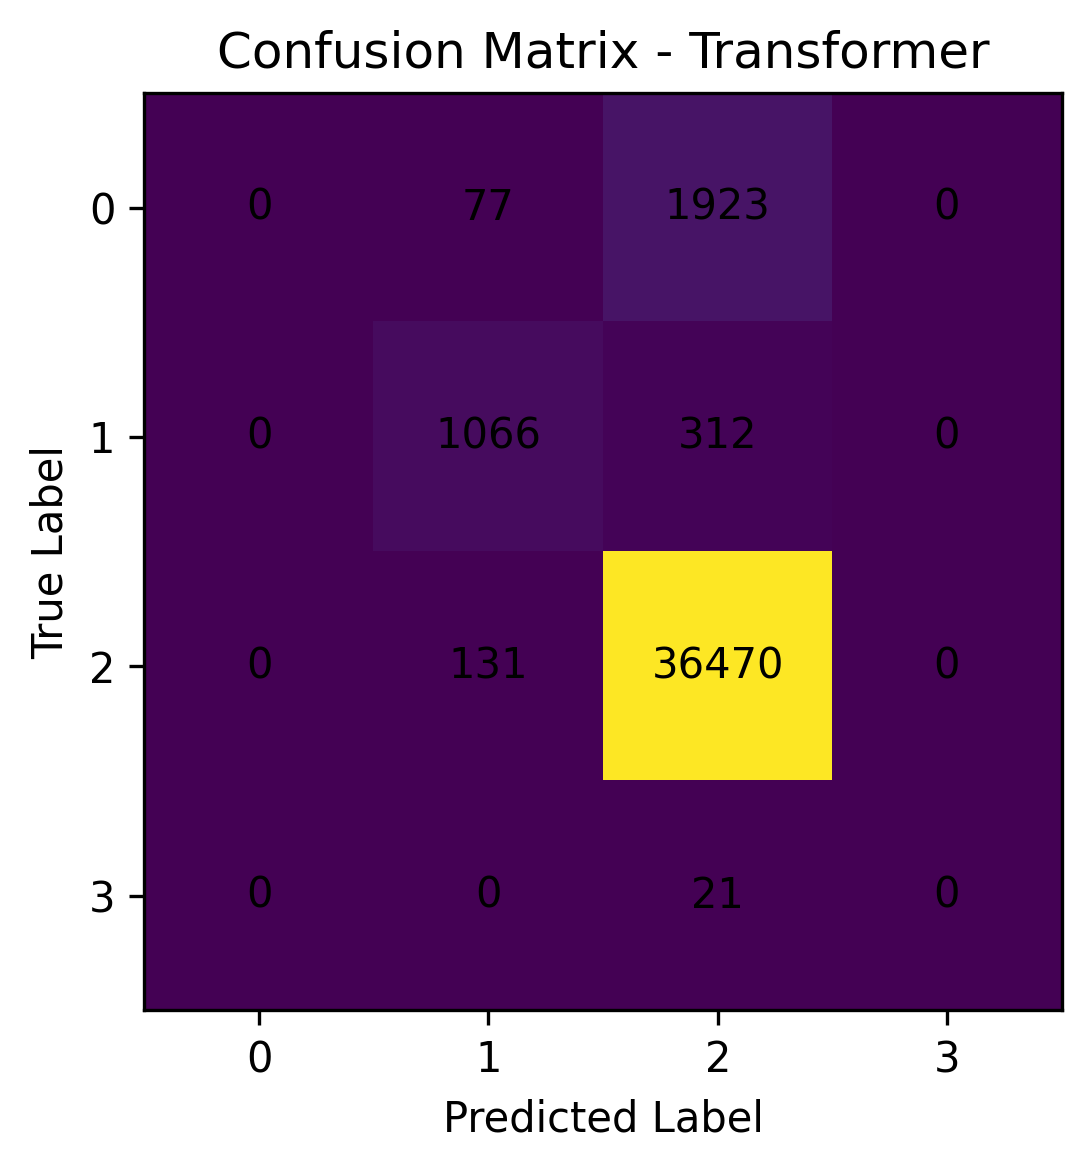

In [21]:
cm_trans = confusion_matrix(y_test, trans_preds)

plt.figure(figsize=(5,4), dpi=300)
plt.imshow(cm_trans)
plt.title("Confusion Matrix - Transformer")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(4))
plt.yticks(range(4))

for i in range(cm_trans.shape[0]):
    for j in range(cm_trans.shape[1]):
        plt.text(j, i, cm_trans[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig("Confusion_Matrix_Transformer.png")
plt.show()


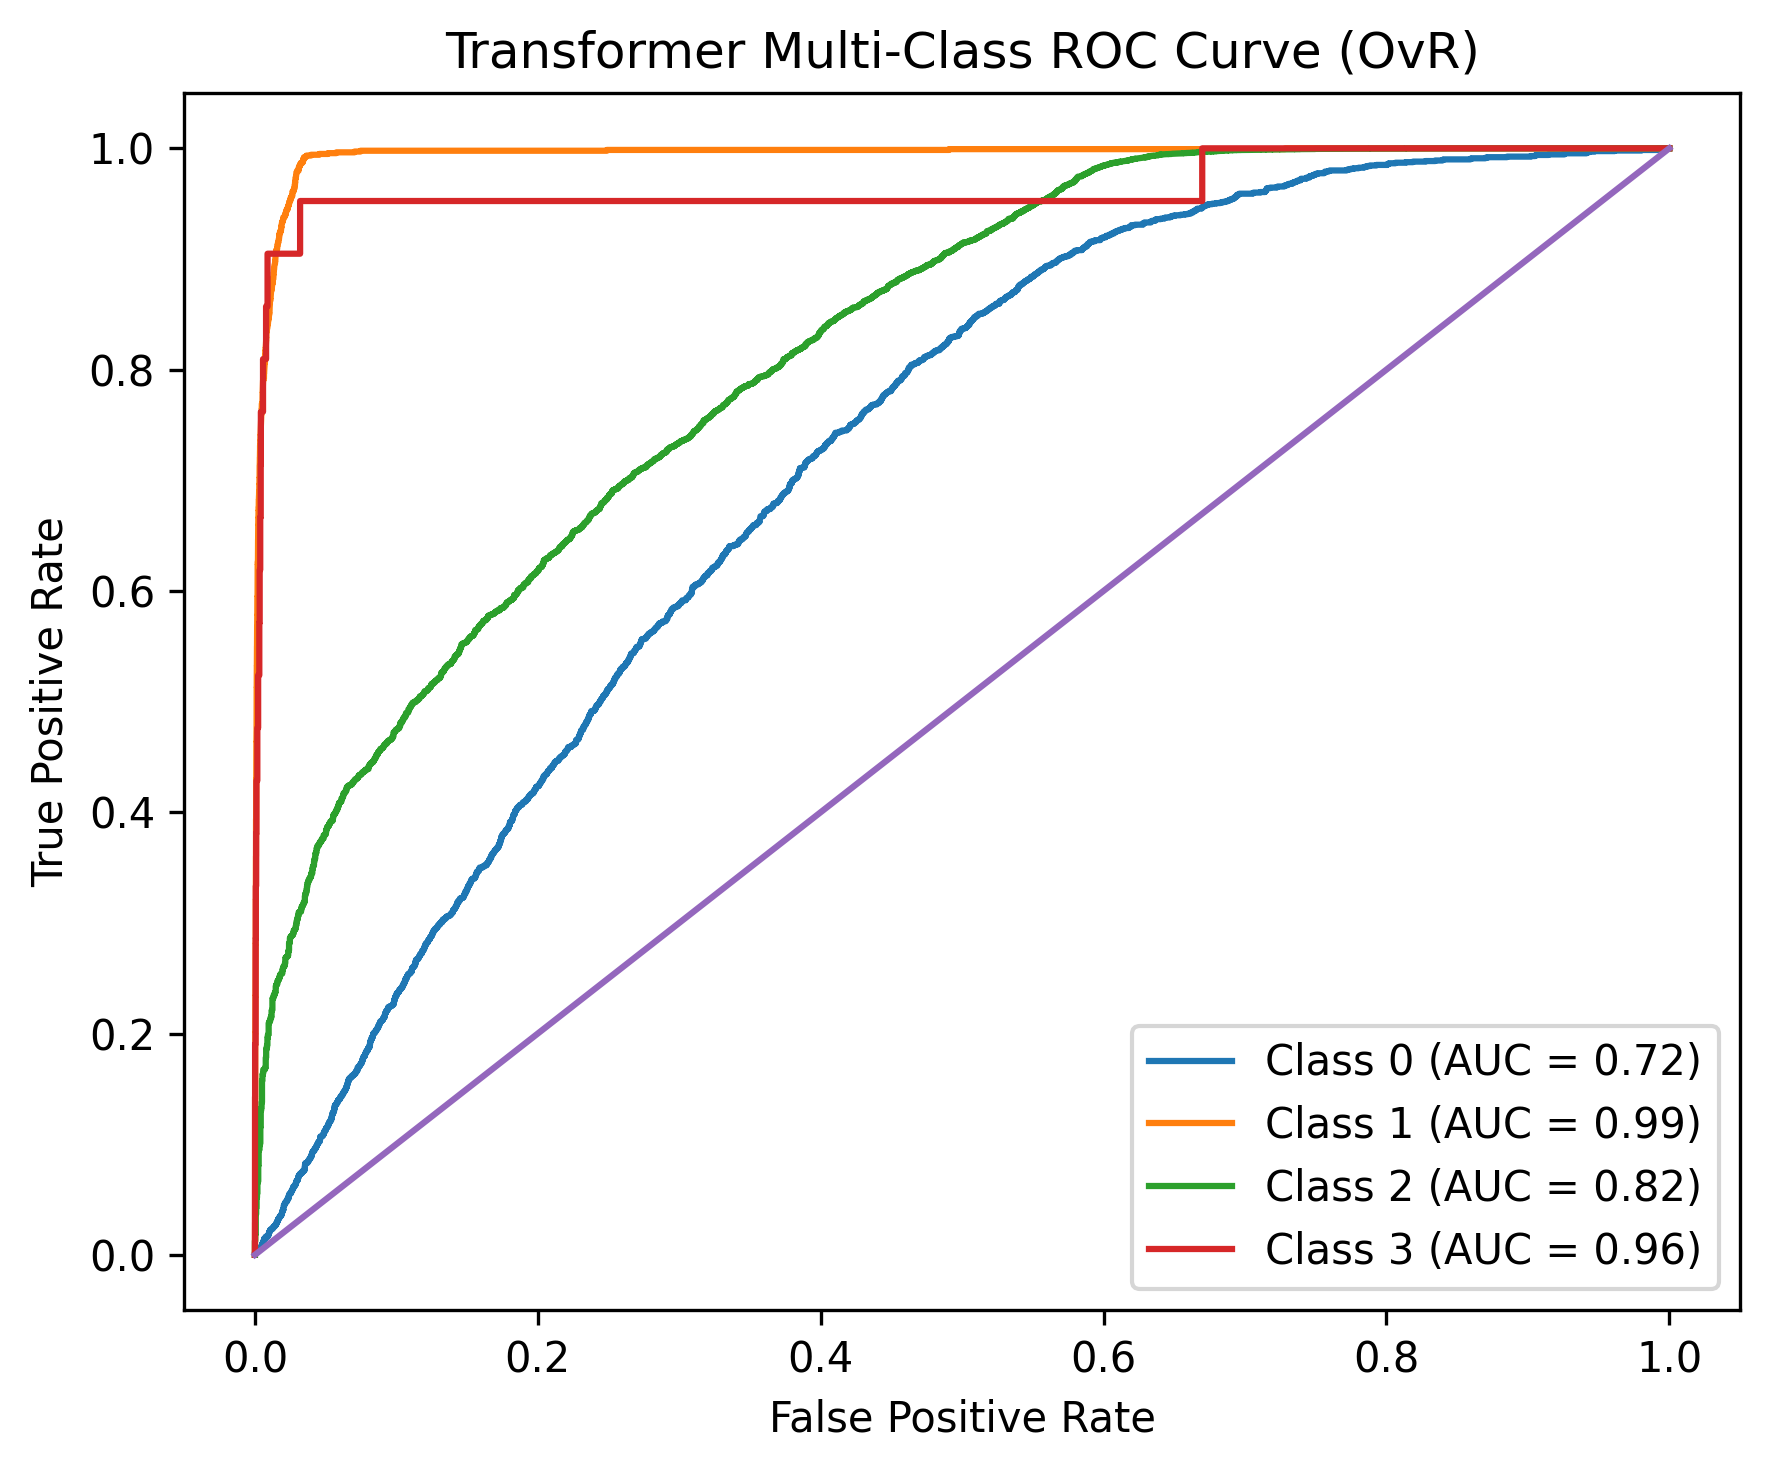

In [22]:
plt.figure(figsize=(6,5), dpi=300)

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], np.array(trans_probs)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Transformer Multi-Class ROC Curve (OvR)")
plt.legend()
plt.tight_layout()
plt.savefig("Transformer_ROC_Curve.png")
plt.show()
